In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.special import erf, spherical_jn

In [13]:
# Parameters
hbarc = 0.2     # eV um
rho_T = 2.0e3   # Sphere density, kg/m^3
mAMU = 1.66e-27 # Neutron mass

# DM parameters
rhoDM = 0.3e9        # dark matter mass density, eV/cm^3

vmin = 5e-5      # minimum velocity to consider, natural units (c)
vesc = 1.815e-3  # galactic escape velocity
v0 = 7.34e-4     # v0 parameter from Zurek group paper
ve = 8.172e-4    # ve parameter from Zurek group paper

nvels = 200      # Number of velocities to include in integration
nq    = 20000    # Number of momentum transfer to sample
qmin  = 10000    # Lowest momenturm transfer considered (eV)

qmax_calc = 100e6 # The maximum momentum transfer to analyze

In [14]:
R_um = 0.083
mx_list_coarser_extended = np.logspace(4, 9, 39)
mx_list_coarse = np.logspace(-1, 4, 77)

alpha_list_coarse = np.logspace(-7, -3, 79)
alpha_list_coarse_extended= np.logspace(-7, 1, 157)

# mx_list = mx_list_coarser_extended[np.logical_and(mx_list_coarser_extended >1e4, mx_list_coarser_extended < 1e8)]
mx_list = mx_list_coarse
alpha_list = alpha_list_coarse

In [15]:
def dsig_domega_born(mx, mphi, alpha, q, R=None, point_charge=True):
    """
    Differential cross section given by Born approximation

    :param mx : DM mass in natural units
    :param phi: mediator mass
    :param q  : momentum transfer (array_like)
    :param point_charge: if True give point charge solution
                         if False include a uniform sphere form factor

    :return: dsigma/domega in natural units (array_like)
    """
    point_charge_sol = (4 * (mx**2) * (alpha**2) ) / ( (mphi**2 + q**2)**2 )
    if point_charge:
        return point_charge_sol
    else:
        form_factor = 3 * spherical_jn(n=1, z=q*R) / (q * R)
        return point_charge_sol * form_factor**2
    
def dsig_dq(dsigdomega, mx, alpha, q, vlist, R):

    ss = np.empty(shape=(vlist.size, q.size))
    ss_out = np.empty(shape=(vlist.size, q.size))

    for i, v in enumerate(vlist):
        p = mx * v
        dsigdq = ( 2 * np.pi * q / (p**2) ) * dsigdomega

        # Cut off contribution below detection
        # Edit 2023/05/19: now done in later stages of analysis
        # dsigdq[q < q_thr] = 0

        # Cut off unphysical large-q scattering
        # This is necessary to get a realistic estimate
        # because Coulomb scattering xsec diverges
        dsigdq[q > 2 * p] = 0
        ss[i] = dsigdq

        # Events outside of sphere only (approximate)
        # From exact sol of Rutherford scattering
        # b = (alpha / 2 Ecm) * cot(theta / 2)
        # q = 2p * sin(theta / 2)
        Ecm = 0.5 * mx * v**2
        bmin = R
        qmax = 2 * p / np.sqrt(4 * Ecm**2 * bmin**2 / alpha**2 + 1)
        dsigdq[q > qmax] = 0
        ss_out[i] = dsigdq
        
    return ss, ss_out


In [16]:
mx_gev = mx_list[20]
alpha_t = alpha_list[30]

R = R_um / hbarc       # Sphere radius, eV^-1
N_T = 0.5 * ( 4/3 * np.pi * (R_um*1e-6)**3 ) * rho_T/mAMU # Number of neutrons

mx = mx_gev * 1e9      # DM mass, eV
alpha = alpha_t * N_T  # Total coupling

pmax = np.min((2.5 * vesc * mx, qmax_calc))
q  = np.linspace(qmin, pmax, nq)

dsigdomega = dsig_domega_born(mx, 0, alpha, q, R=None, point_charge=True)
dsigdomega_withr = dsig_domega_born(mx, 0, alpha, q, R=R, point_charge=False)

In [25]:
form_factor

array([ 1.74024792e-07,  1.55627122e-07,  1.36003035e-07, ...,
       -1.86141645e-13, -1.94358461e-13, -1.97565892e-13])

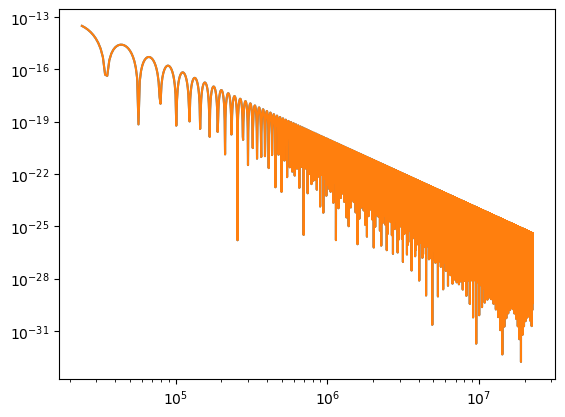

In [26]:
form_factor = 3 * spherical_jn(n=1, z=q*R) / (q * R)
form_factor_2 = 3 * (np.sin(q*R) - q * R * np.cos(q*R)) / ((q * R)**3)

plt.plot(q / R, form_factor_2**2)
plt.plot(q / R, form_factor**2)

plt.yscale('log')
plt.xscale('log')

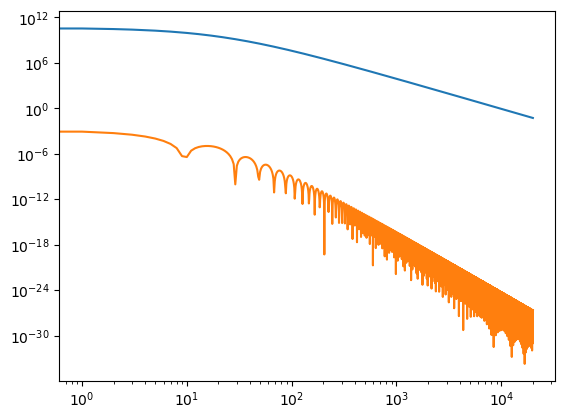

In [18]:
plt.plot(dsigdomega)
plt.plot(dsigdomega_withr)

plt.yscale('log')
plt.xscale('log')